# Nested Cross-Validation: Final Model Validation

## Robust Performance Estimation for Top 3 Models

This notebook implements **nested cross-validation** for model performance estimation.

**Nested CV Structure:**
- **Outer loop (5-fold):** Estimates true model performance
- **Inner loop (5-fold):** Hyperparameter tuning via GridSearchCV

**Models evaluated:**
1. Logistic Regression
2. Support Vector Machine (SVM)
3. XGBoost (Gradient Boosting)

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (12, 8)

## 2. Load Data

In [2]:
# Load SNP features and labels
snp_data = pd.read_csv('snps_cleaned_SXT.csv', index_col=0)
profiles = pd.read_csv('SXT.csv', index_col=0)

X = snp_data.values
y = profiles.values

print(f"Data shape: {X.shape}")
print(f"Label shape: {y.shape}")
print(f"Categories: {np.unique(y)}")

Data shape: (227, 9754)
Label shape: (227, 1)
Categories: [0 1]


## 3. Nested Cross-Validation Implementation

### 3.1 Define Nested CV Function

In [3]:
def nested_cross_validation(model_name, pipeline, param_grid, X, y, cv_outer=5, cv_inner=5):
    """
    Perform nested cross-validation for model evaluation.
    Returns a dictionary with nested CV results
    """
    
    # Setup outer cross-validation
    cv_outer_splitter = StratifiedKFold(n_splits=cv_outer, shuffle=True, random_state=42)
    
    # Store results for each outer fold
    outer_accuracies = []
    outer_aucs = []
    best_params_list = []
    
    fold = 1
    for train_idx, test_idx in cv_outer_splitter.split(X, y):
        # Split data
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        # Inner cross-validation (hyperparameter tuning)
        grid_search = GridSearchCV(
            pipeline,
            param_grid,
            cv=StratifiedKFold(n_splits=cv_inner, shuffle=True, random_state=42),
            scoring='accuracy',
            n_jobs=-1,
            verbose=0
        )
        
        # Fit on training data
        grid_search.fit(X_train, y_train)
        
        # Evaluate on test data
        y_pred = grid_search.predict(X_test)
        y_proba = grid_search.predict_proba(X_test)[:, 1]
        
        accuracy = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        
        outer_accuracies.append(accuracy)
        outer_aucs.append(auc)
        best_params_list.append(grid_search.best_params_)
        
        print(f'{model_name} - Fold {fold}: Accuracy={accuracy:.4f}, AUC={auc:.4f}')
        fold += 1
    
    # Return summary statistics
    results = {
        'model_name': model_name,
        'accuracies': np.array(outer_accuracies),
        'aucs': np.array(outer_aucs),
        'accuracy_mean': np.mean(outer_accuracies),
        'accuracy_std': np.std(outer_accuracies),
        'accuracy_ci': 1.96 * np.std(outer_accuracies) / np.sqrt(cv_outer),
        'auc_mean': np.mean(outer_aucs),
        'auc_std': np.std(outer_aucs),
        'auc_ci': 1.96 * np.std(outer_aucs) / np.sqrt(cv_outer),
        'best_params_list': best_params_list
    }
    
    return results

### 3.2 Define Models and Hyperparameter Grids

In [4]:
# Define pipelines and hyperparameter grids

# 1. Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

lr_param_grid = {
    'logreg__C': np.logspace(-2, 3, 6)  # 0.01 to 1000
}

# 2. Support Vector Machine
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, random_state=42))
])

svm_param_grid = {
    'svm__kernel': ['linear', 'rbf'],
    'svm__C': [0.1, 1, 10]
}

# 3. XGBoost
xgb_pipeline = Pipeline([
    ('xgb', xgb.XGBClassifier(
        n_estimators=100,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
        use_label_encoder=False,
        eval_metric='logloss'
    ))
])

xgb_param_grid = {
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.1],
    'xgb__reg_alpha': [0.0, 1.0]
}

print('Models and hyperparameter grids defined')

Models and hyperparameter grids defined


### 3.3 Run Nested Cross-Validation

In [5]:
results_lr = nested_cross_validation(
    'Logistic Regression',
    lr_pipeline,
    lr_param_grid,
    X, y
)
print()

results_svm = nested_cross_validation(
    'SVM',
    svm_pipeline,
    svm_param_grid,
    X, y
)
print()

results_xgb = nested_cross_validation(
    'XGBoost',
    xgb_pipeline,
    xgb_param_grid,
    X, y
)
print()

NESTED CROSS-VALIDATION RESULTS
Logistic Regression - Fold 1: Accuracy=0.8478, AUC=0.8695
Logistic Regression - Fold 2: Accuracy=0.8478, AUC=0.8343
Logistic Regression - Fold 3: Accuracy=0.7778, AUC=0.7800
Logistic Regression - Fold 4: Accuracy=0.7333, AUC=0.8849
Logistic Regression - Fold 5: Accuracy=0.8889, AUC=0.8958

SVM - Fold 1: Accuracy=0.8261, AUC=0.8933
SVM - Fold 2: Accuracy=0.8478, AUC=0.9162
SVM - Fold 3: Accuracy=0.7333, AUC=0.8620
SVM - Fold 4: Accuracy=0.7556, AUC=0.9167
SVM - Fold 5: Accuracy=0.8667, AUC=0.9206

XGBoost - Fold 1: Accuracy=0.7609, AUC=0.8705
XGBoost - Fold 2: Accuracy=0.8043, AUC=0.8914
XGBoost - Fold 3: Accuracy=0.6889, AUC=0.7940
XGBoost - Fold 4: Accuracy=0.8000, AUC=0.8988
XGBoost - Fold 5: Accuracy=0.7556, AUC=0.8274



## 4. Results Summary

In [6]:
# Compile results
all_results = [results_lr, results_svm, results_xgb]

# Create summary dataframe
summary_data = []
for res in all_results:
    summary_data.append({
        'Model': res['model_name'],
        'Accuracy': f"{res['accuracy_mean']:.4f} ± {res['accuracy_std']:.4f}",
        'Accuracy (95% CI)': f"[{res['accuracy_mean']-res['accuracy_ci']:.4f}, {res['accuracy_mean']+res['accuracy_ci']:.4f}]",
        'AUC': f"{res['auc_mean']:.4f} ± {res['auc_std']:.4f}",
        'AUC (95% CI)': f"[{res['auc_mean']-res['auc_ci']:.4f}, {res['auc_mean']+res['auc_ci']:.4f}]"
    })

summary_df = pd.DataFrame(summary_data)
print('\nNested Cross-Validation Summary:')
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('nested_cv_results.csv', index=False)
print('\nResults saved to nested_cv_results.csv')


Nested Cross-Validation Summary:
              Model        Accuracy Accuracy (95% CI)             AUC     AUC (95% CI)
Logistic Regression 0.8191 ± 0.0558  [0.7702, 0.8681] 0.8529 ± 0.0420 [0.8161, 0.8897]
                SVM 0.8059 ± 0.0523  [0.7601, 0.8517] 0.9018 ± 0.0221 [0.8824, 0.9211]
            XGBoost 0.7619 ± 0.0415  [0.7255, 0.7983] 0.8564 ± 0.0399 [0.8214, 0.8914]

Results saved to nested_cv_results.csv


## 5. Visualizations

### 5.1 Accuracy Comparison with Error Bars

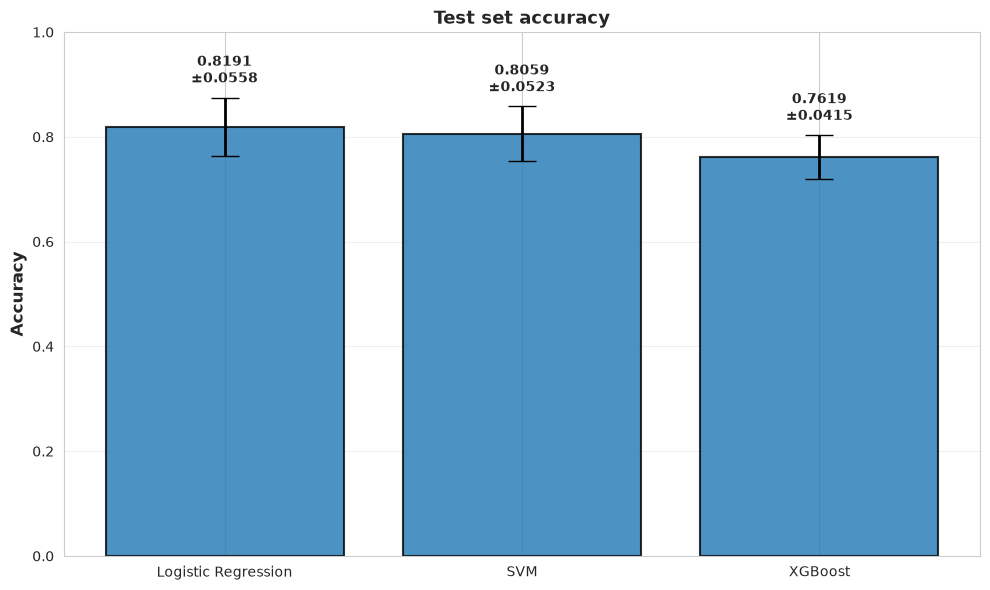

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

models = [res['model_name'] for res in all_results]
accuracies = [res['accuracy_mean'] for res in all_results]
stds = [res['accuracy_std'] for res in all_results]
bars = ax.bar(models, accuracies, yerr=stds, capsize=10, alpha=0.8, edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2})

# Add value labels
for i, (bar, acc, std) in enumerate(zip(bars, accuracies, stds)):
    ax.text(bar.get_x() + bar.get_width()/2, acc + std + 0.02,
            f'{acc:.4f}\n±{std:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Test set accuracy', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nested_cv_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.2 AUC Comparison with Error Bars

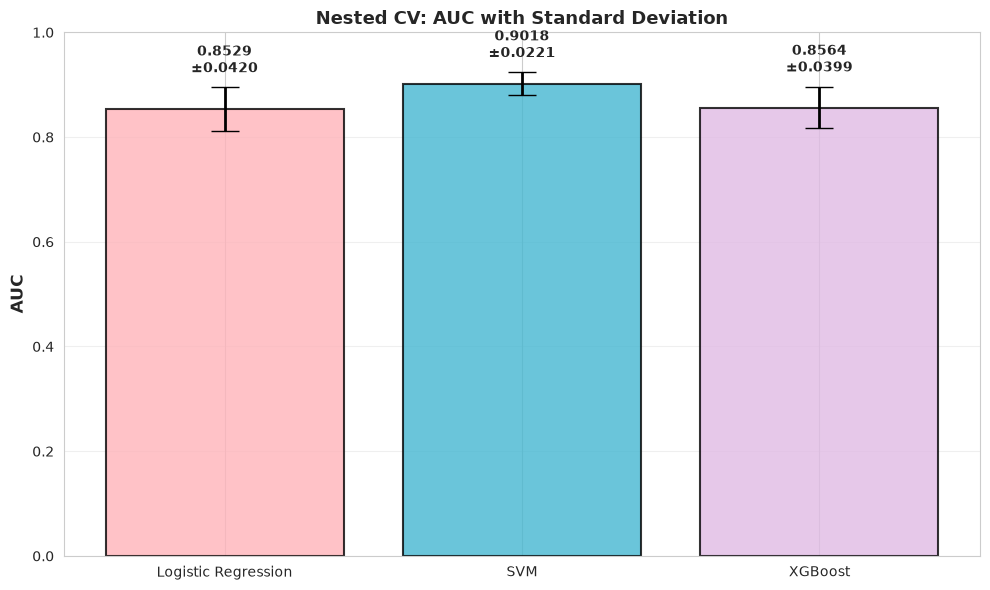

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

aucs = [res['auc_mean'] for res in all_results]
auc_stds = [res['auc_std'] for res in all_results]
colors = ['#FFB3BA', '#45B7D1', '#E0BBE4']

bars = ax.bar(models, aucs, yerr=auc_stds, capsize=10, alpha=0.8,
              color=colors, edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2})

# Add value labels
for i, (bar, auc, std) in enumerate(zip(bars, aucs, auc_stds)):
    ax.text(bar.get_x() + bar.get_width()/2, auc + std + 0.02,
            f'{auc:.4f}\n±{std:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('AUC', fontsize=12, fontweight='bold')
ax.set_title('Nested CV: AUC with Standard Deviation', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('nested_cv_auc.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.3 Fold-by-Fold Accuracy Comparison

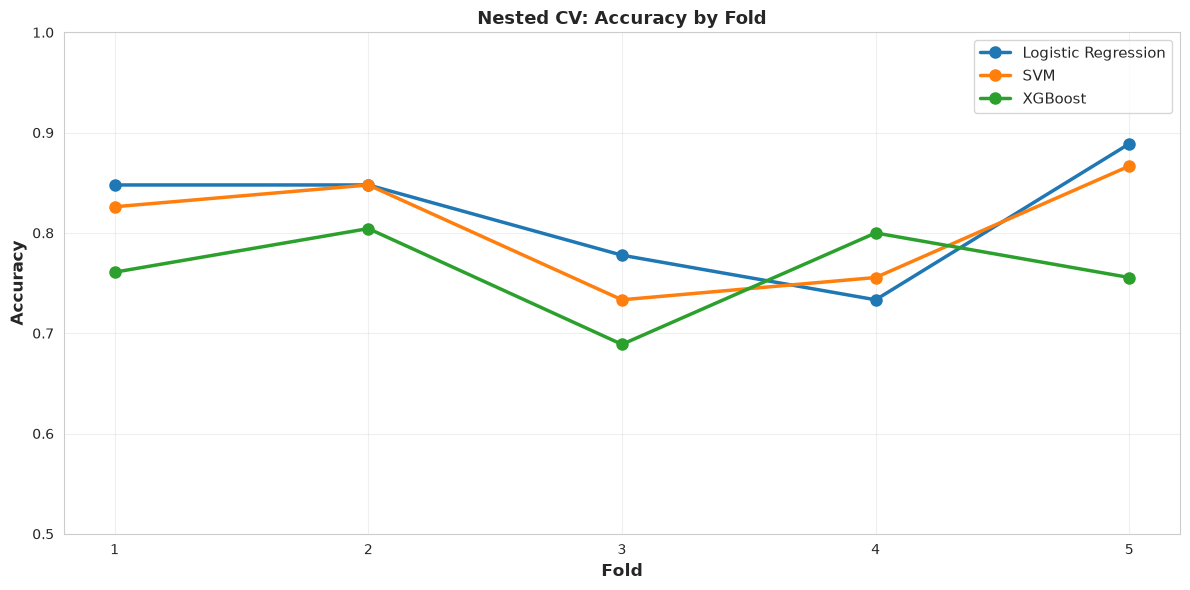

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

folds = np.arange(1, 6)
for i, res in enumerate(all_results):
    ax.plot(folds, res['accuracies'], 'o-', linewidth=2.5, markersize=8,
            label=res['model_name'])

ax.set_xlabel('Fold', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Nested CV: Accuracy by Fold', fontsize=13, fontweight='bold')
ax.set_xticks(folds)
ax.set_ylim([0.5, 1.0])
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('nested_cv_folds.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Conclusions

In [18]:
# Rank models by accuracy
ranked = sorted(all_results, key=lambda x: x['accuracy_mean'], reverse=True)

print('\nModel Rankings (by Accuracy):')
for i, res in enumerate(ranked, 1):
    print(f"{i}. {res['model_name']:25s} {res['accuracy_mean']:.3f} ± {res['accuracy_std']:.3f}")

print(f"\nBest model: {ranked[0]['model_name']}")
print(f"Mean accuracy: {ranked[0]['accuracy_mean']:.3f}")
print(f"std: {ranked[0]['accuracy_std']:.3f}")



Model Rankings (by Accuracy):
1. Logistic Regression       0.819 ± 0.056
2. SVM                       0.806 ± 0.052
3. XGBoost                   0.762 ± 0.042

Best model: Logistic Regression
Mean accuracy: 0.819
std: 0.056
